# DNNWG on MNIST CNN Zoo

It covers:

1. Collecting and loading the model zoo  
2. Flattening weights and preparing the DNNWG-compatible folder layout  
3. Training the **stage-1 VAE**  
4. Training the **stage-2 latent diffusion model**  
5. Sampling new weight vectors  
6. Evaluating sampled networks on MNIST  
7. Plotting **PyTorch Lightning** training logs for stage 1 and stage 2


## remove warnings

In [10]:
import warnings
import os

# Suppress all Python warnings
warnings.filterwarnings("ignore")

# Suppress specific noisy warnings (optional fine-tuning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Silence PyTorch Lightning + other verbose logs
os.environ["PYTHONWARNINGS"] = "ignore"

# Optional: reduce Lightning logging noise
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)

## 0. Paths

In [24]:
from pathlib import Path

# --- project / repo paths ---
REPO_ROOT = Path(r"D:\לימודים\תואר שני\מחקר\DNNWG")                      # change me
DATA_ROOT = Path(r"D:\DataWerehouse\model_zoo")           # change me
MODEL_ZOO_ROOT = Path(r"D:\לימודים\תואר שני\מחקר\ModelZooDataset")
RAW_ZOO_FILE = DATA_ROOT / "dataset_mnist_seed.pt"
FLAT_ZOO_FILE = DATA_ROOT / "dataset_mnist_flat.pt"
DNNWG_LAYOUT_ROOT = DATA_ROOT / "dnnwg_mnist"

# --- logs / checkpoints ---
STAGE1_CONFIG = REPO_ROOT / "checkpoints" / "stage1" / "config.yaml"
STAGE2_CONFIG = REPO_ROOT / "checkpoints" / "stage2" / "config.yaml"
STAGE1_CKPT = REPO_ROOT / "vae_checkpoints" / "checkpoint_vae_model_epoch-14_.ckpt"  # change me
STAGE2_CKPT = REPO_ROOT / "ldm_checkpoints" / "checkpoint_ldm_model.pt"               # change me

# --- condition file / samples ---
COND_FILE = REPO_ROOT / "clip_encode_dsets_20_cond_.pt"
SAMPLED_WEIGHTS_FILE = REPO_ROOT / "generated_weights_mnist.pt"  # change me if sampling saves elsewhere

# --- lightning log files ---
# update these to the actual metrics.csv paths generated during training
STAGE1_METRICS = REPO_ROOT / "lightning_logs" / "version_0" / "metrics.csv"
STAGE2_METRICS = REPO_ROOT / "lightning_logs" / "version_1" / "metrics.csv"

print("REPO_ROOT:", REPO_ROOT)
print("RAW_ZOO_FILE exists:", RAW_ZOO_FILE.exists())
print("FLAT_ZOO_FILE exists:", FLAT_ZOO_FILE.exists())
print("COND_FILE exists:", COND_FILE.exists())


REPO_ROOT: D:\לימודים\תואר שני\מחקר\DNNWG
RAW_ZOO_FILE exists: True
FLAT_ZOO_FILE exists: True
COND_FILE exists: True


## 1. Collecting the zoo

We used the **MNIST CNN zoo** because it is small enough to get the pipeline working end-to-end.

https://zenodo.org/records/6632087

The raw file loads into a dict containing:
- `trainset`
- `valset`
- `testset`

Each sample is an `OrderedDict` / `state_dict` of tensor parameters.


In [11]:
import torch
import pathlib
import sys
sys.path.insert(0,str(MODEL_ZOO_ROOT/"code"))

# If the raw zoo was saved on Linux and loaded on Windows, this monkey-patch may be needed.
if hasattr(pathlib, "WindowsPath"):
    pathlib.PosixPath = pathlib.WindowsPath

raw_data = torch.load(RAW_ZOO_FILE, map_location="cpu", weights_only=False)
print(raw_data.keys())

trainset = raw_data["trainset"]
sample = trainset[0]
print(type(sample))
for k, v in sample.items():
    print(k, tuple(v.shape), v.numel())


dict_keys(['trainset', 'valset', 'testset'])
<class 'collections.OrderedDict'>
module_list.0.weight (8, 1, 5, 5) 200
module_list.0.bias (8,) 8
module_list.3.weight (6, 8, 5, 5) 1200
module_list.3.bias (6,) 6
module_list.6.weight (4, 6, 2, 2) 96
module_list.6.bias (4,) 4
module_list.9.weight (20, 36) 720
module_list.9.bias (20,) 20
module_list.11.weight (10, 20) 200
module_list.11.bias (10,) 10


## 2. Flattening the zoo

The DNNWG run described here used a CNN whose true parameter vector length was **2464**.

The stage-1 and stage-2 loaders later padded these vectors to **2864**.


In [9]:
def flatten_state_dict(sd):
    return torch.cat([v.detach().float().reshape(-1) for v in sd.values()])

train_vectors = torch.stack([flatten_state_dict(raw_data["trainset"][i]) for i in range(len(raw_data["trainset"]))])
val_vectors   = torch.stack([flatten_state_dict(raw_data["valset"][i]) for i in range(len(raw_data["valset"]))])
test_vectors  = torch.stack([flatten_state_dict(raw_data["testset"][i]) for i in range(len(raw_data["testset"]))])

print("train:", train_vectors.shape)
print("val  :", val_vectors.shape)
print("test :", test_vectors.shape)

# torch.save(
#     {"trainset": train_vectors, "valset": val_vectors, "testset": test_vectors},
#     FLAT_ZOO_FILE
# )
# print("saved:", FLAT_ZOO_FILE)


train: torch.Size([35604, 2464])
val  : torch.Size([7606, 2464])
test : torch.Size([7650, 2464])


## 3. Preparing the DNNWG folder layout

The DNNWG loaders expected files under:

```text
root/
  weights/
    train_data.pt
    val_data.pt
    test_data.pt
```

and for stage 2 specifically we also duplicated them *without* `.pt` suffix because the sampler used those names.


In [12]:
from pathlib import Path
import shutil

weights_dir = DNNWG_LAYOUT_ROOT / "weights"
# weights_dir.mkdir(parents=True, exist_ok=True)

flat = torch.load(FLAT_ZOO_FILE, map_location="cpu", weights_only=False)
torch.save({"mnist": [flat["trainset"]]}, weights_dir / "train_data.pt")
torch.save({"mnist": [flat["valset"]]},   weights_dir / "val_data.pt")
torch.save({"mnist": [flat["testset"]]},  weights_dir / "test_data.pt")

# stage-2 sampler expected files without the .pt suffix
# for name in ["train_data", "val_data", "test_data"]:
#     shutil.copyfile(weights_dir / f"{name}.pt", weights_dir / name)

print("prepared:", weights_dir)
print(sorted(p.name for p in weights_dir.iterdir()))


prepared: D:\DataWerehouse\model_zoo\dnnwg_mnist\weights
['test_data', 'test_data.pt', 'train_data', 'train_data.pt', 'val_data', 'val_data.pt']


## 4. Stage-1 VAE

Stage 1 trains a **VAE over weight vectors**.

The repo padded weight vectors to length **2864**, and the trained stage-1 VAE was used later by the stage-2 latent diffusion model.

### What stage 1 learns
- encoder: weight vector → latent representation
- decoder: latent representation → reconstructed weight vector

### Why stage 1 matters
Stage 2 does **not** diffuse over raw weights directly. It diffuses in the latent space produced by the VAE.


### Stage-1 commands

From the repo root, the usual flow was:

```bash
python main.py --base checkpoints/stage1/config.yaml
```

with a config adapted for:
- `in_dim: 2864`
- local dataset folder
- local checkpoints


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

def load_metrics(path):
    df = pd.read_csv(path)
    print("columns:")
    print(list(df.columns))
    return df

stage1_df = load_metrics(STAGE1_METRICS)
stage1_df.head()


columns:
['epoch', 'step', 'train/aeloss_epoch', 'train/aeloss_step', 'train/kl_loss', 'train/logvar', 'train/nll_loss', 'train/rec_loss', 'train/total_loss', 'val/rec_loss']


,epoch,step,train/aeloss_epoch,train/aeloss_step,train/kl_loss,train/logvar,train/nll_loss,train/rec_loss,train/total_loss,val/rec_loss
0,0,0,NaN,1374.970093,1.004319e+02,0.0,1374.969971,0.480087,1374.970093,NaN
1,0,1,NaN,16995.189453,1.845568e+03,0.0,16995.187500,5.934073,16995.189453,NaN
2,0,2,NaN,2229.138184,5.500695e+08,0.0,1679.068604,0.586267,2229.138184,NaN
3,0,3,NaN,3925.759277,4.050836e+02,0.0,3925.758789,1.370726,3925.759277,NaN
4,0,4,NaN,1955.451538,8.107496e+02,0.0,1955.450684,0.682769,1955.451538,NaN


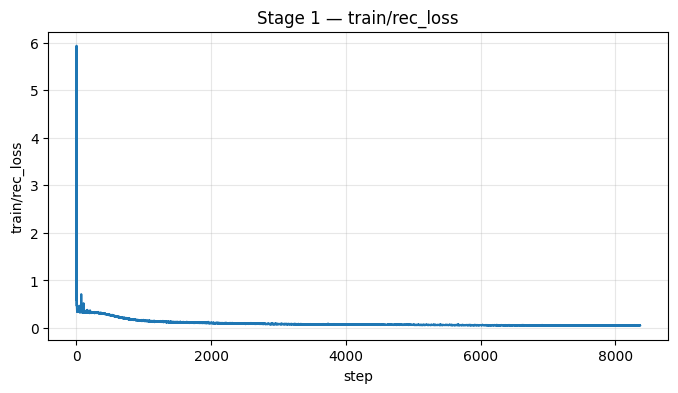

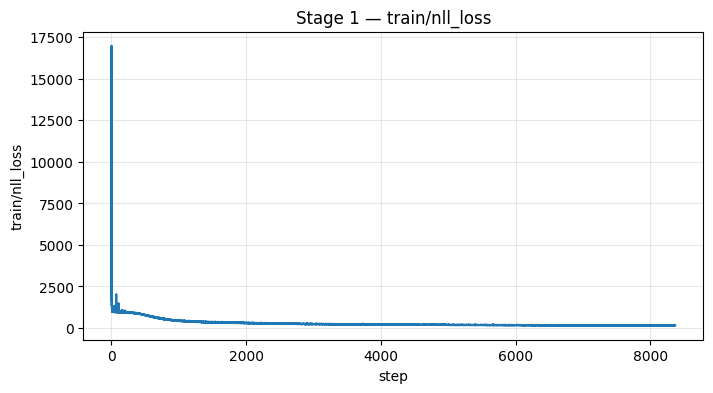

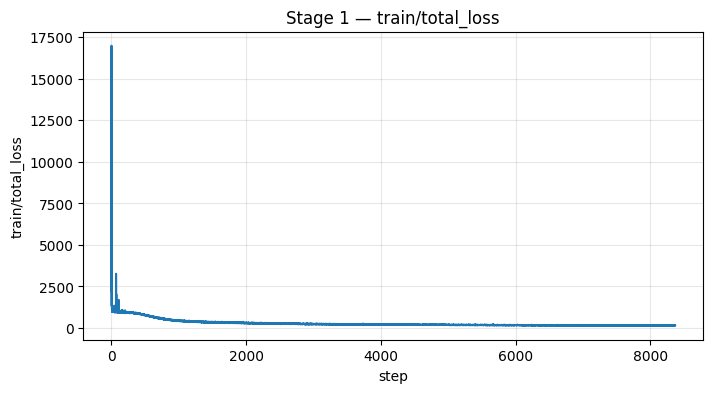

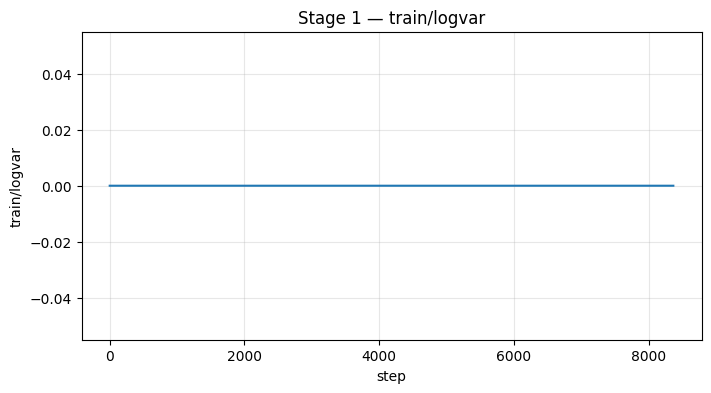

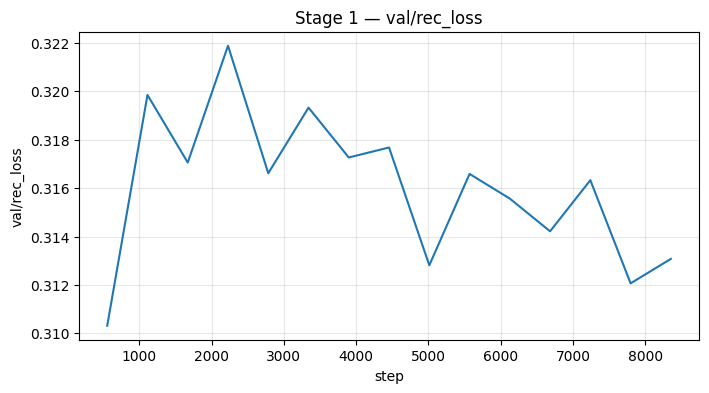

In [17]:
# Simple plot helper
def plot_metric(df, y, x="step", title=None):
    tmp = df[[x, y]].dropna()
    if tmp.empty:
        print(f"No data for {y}")
        return
    plt.figure(figsize=(8, 4))
    plt.plot(tmp[x], tmp[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title or y)
    plt.grid(True, alpha=0.3)
    plt.show()

# Typical stage-1 metrics
for col in [
    "train/rec_loss",
    "train/nll_loss",
    "train/total_loss",
    "train/logvar",
    "val/rec_loss",
]:
    if col in stage1_df.columns:
        plot_metric(stage1_df, col, x="step", title=f"Stage 1 — {col}")


### Optional: stage-1 epoch summary view


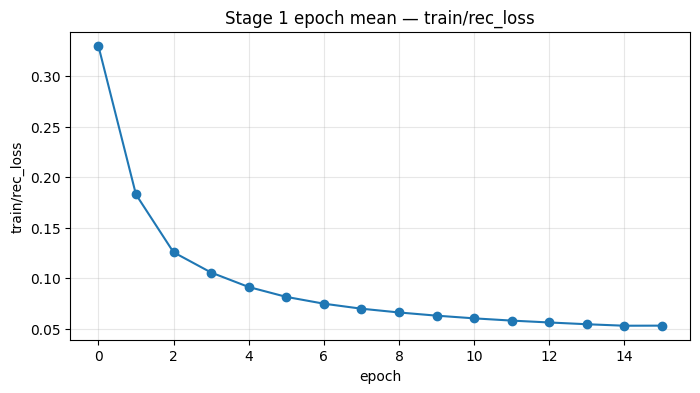

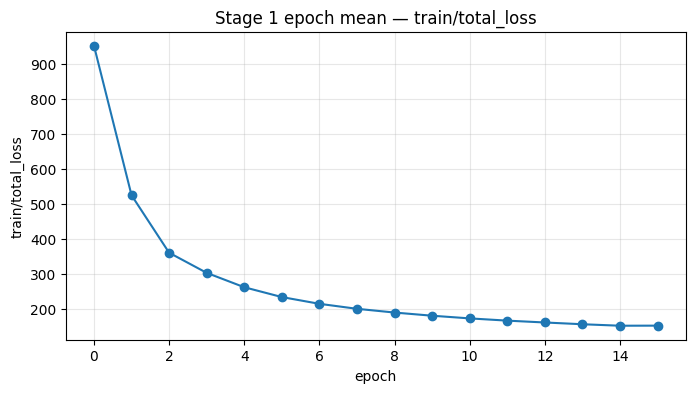

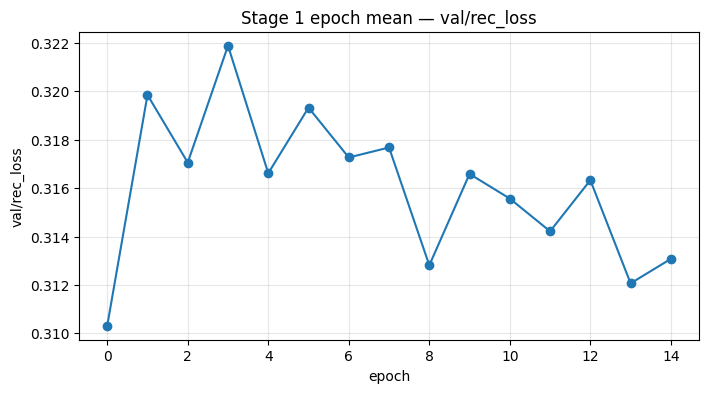

In [18]:
# If epoch-level columns exist, this makes it easier to see the plateau.
if "epoch" in stage1_df.columns:
    for col in ["train/rec_loss", "train/total_loss", "val/rec_loss"]:
        if col in stage1_df.columns:
            tmp = stage1_df[["epoch", col]].dropna().groupby("epoch", as_index=False).mean()
            plt.figure(figsize=(8, 4))
            plt.plot(tmp["epoch"], tmp[col], marker="o")
            plt.xlabel("epoch")
            plt.ylabel(col)
            plt.title(f"Stage 1 epoch mean — {col}")
            plt.grid(True, alpha=0.3)
            plt.show()


## 6. Conditioning data

The original pipeline used `compute_condition.py` to build CLIP-based conditioning features.

For MNIST, this produced condition tensors with structure:

```text
[num_classes, num_sample, clip_dim] = [10, 5, 512]
```

and after batching:

```text
[batch_size, 10, 5, 512]
```


In [19]:
conds = torch.load(COND_FILE, map_location="cpu", weights_only=False)
print(type(conds))
print(conds.keys())

mnist_cond = conds["mnist"]
print(type(mnist_cond))
for k, v in mnist_cond.items():
    print("class:", k, "shape:", tuple(v.shape), "dtype:", v.dtype)
    break


<class 'dict'>
dict_keys(['mnist', 'svhn', 'cifar10', 'stl10'])
<class 'dict'>
class: 0 shape: (20, 512) dtype: torch.float16


## 7. Stage-2 latent diffusion

Stage 2 trains a diffusion model in the VAE latent space.

### What stage 2 learns
- input: noisy latent + timestep + condition
- target: either noise (`eps`) or clean latent (`x0`)

In our run, the model was in **eps-prediction** mode, so it learned to predict the added noise.


### Stage-2 commands

From the repo root:

```bash
python dtrainer.py --base checkpoints/stage2/config.yaml
```

The stage-2 config needed:
- `first_stage_config.params.ckpt_path` pointing to the stage-1 checkpoint
- `data_dir` pointing to the prepared MNIST zoo layout
- `dataset: "mnist"`
- condition encoder enabled


## 8. Plotting stage-2 Lightning logs

These are the most important stage-2 metrics:
- `train/loss_simple_epoch`
- `train/loss_simple_step`
- `val/loss_simple`
- `train/loss`
- `val/loss`


In [20]:
stage2_df = load_metrics(STAGE2_METRICS)
stage2_df.head()


columns:
['epoch', 'global_step', 'lr_abs', 'step', 'train/loss_epoch', 'train/loss_simple_epoch', 'train/loss_simple_step', 'train/loss_step', 'train/loss_vlb_epoch', 'train/loss_vlb_step', 'val/loss', 'val/loss_ema', 'val/loss_simple', 'val/loss_simple_ema', 'val/loss_vlb', 'val/loss_vlb_ema']


,epoch,global_step,lr_abs,step,train/loss_epoch,train/loss_simple_epoch,train/loss_simple_step,train/loss_step,train/loss_vlb_epoch,train/loss_vlb_step,val/loss,val/loss_ema,val/loss_simple,val/loss_simple_ema,val/loss_vlb,val/loss_vlb_ema
0,0,0.0,1.133000e-10,0,NaN,NaN,1.001480,1.001480,NaN,0.013288,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1.0,1.144329e-08,1,NaN,NaN,0.995999,0.995999,NaN,0.007482,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2.0,2.277328e-08,2,NaN,NaN,0.997627,0.997627,NaN,0.007233,NaN,NaN,NaN,NaN,NaN,NaN
3,0,3.0,3.410327e-08,3,NaN,NaN,0.999254,0.999254,NaN,0.005665,NaN,NaN,NaN,NaN,NaN,NaN
4,0,4.0,4.543325e-08,4,NaN,NaN,0.990351,0.990351,NaN,0.009719,NaN,NaN,NaN,NaN,NaN,NaN


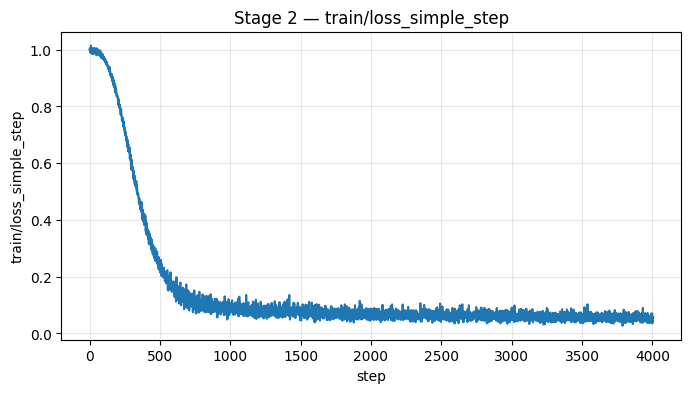

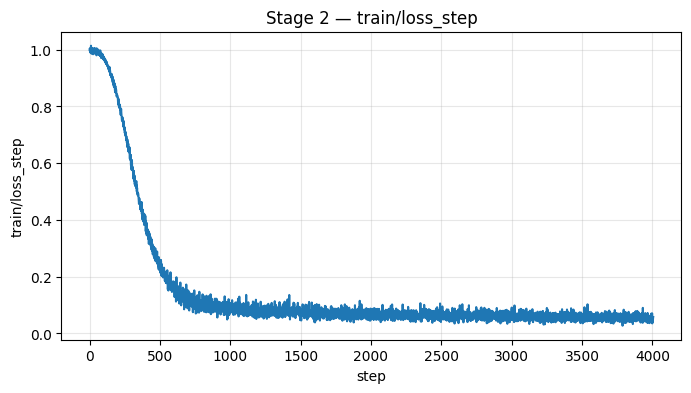

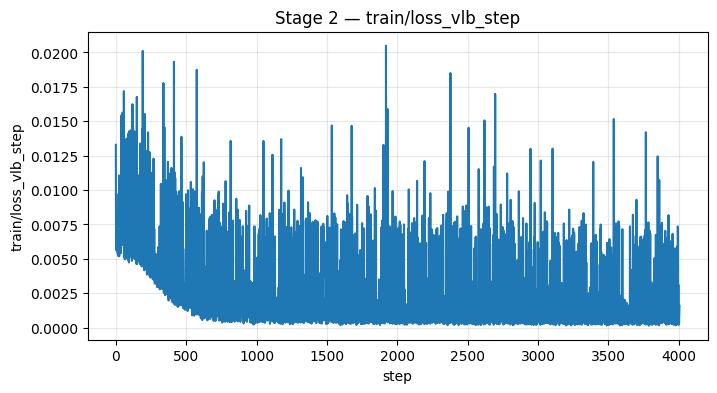

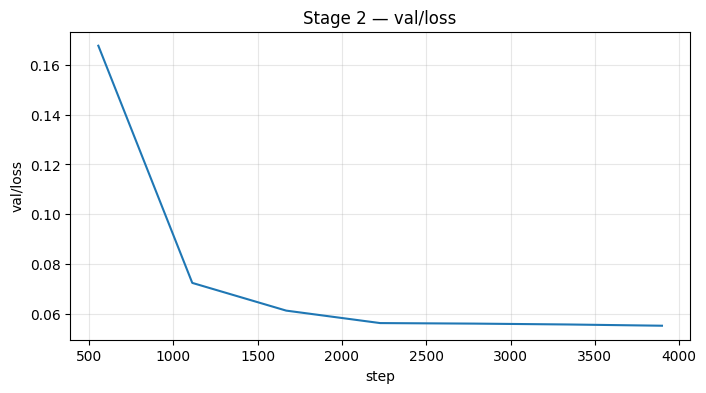

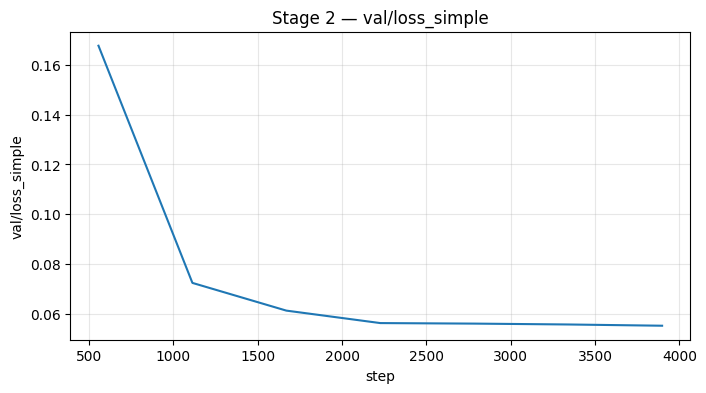

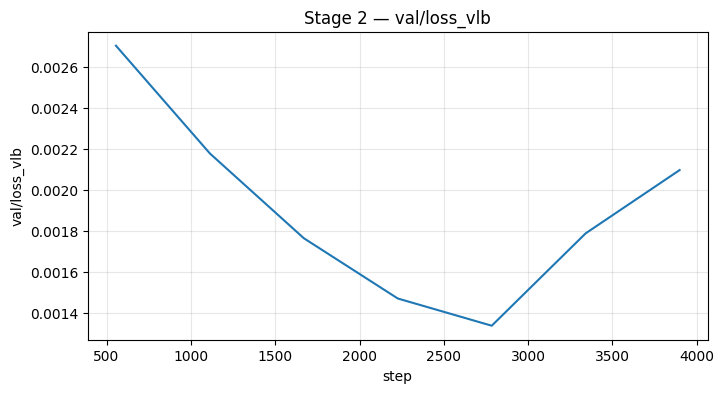

In [21]:
for col in [
    "train/loss_simple_step",
    "train/loss_step",
    "train/loss_vlb_step",
    "val/loss",
    "val/loss_simple",
    "val/loss_vlb",
]:
    if col in stage2_df.columns:
        plot_metric(stage2_df, col, x="step", title=f"Stage 2 — {col}")


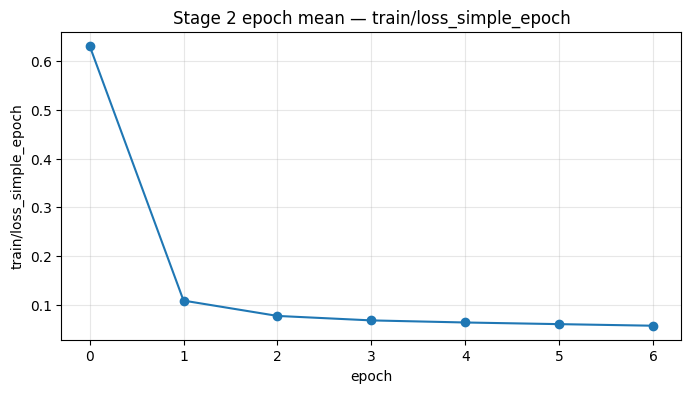

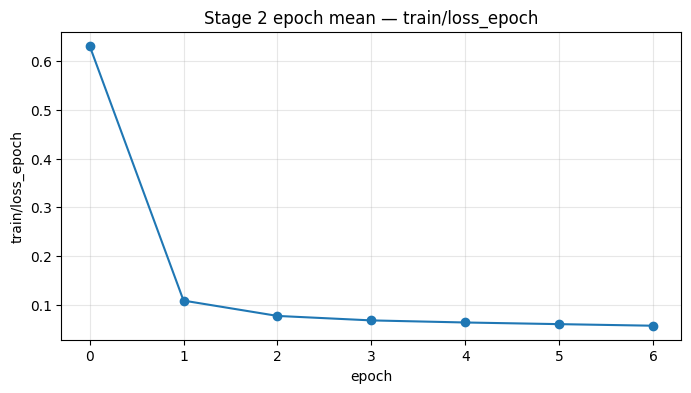

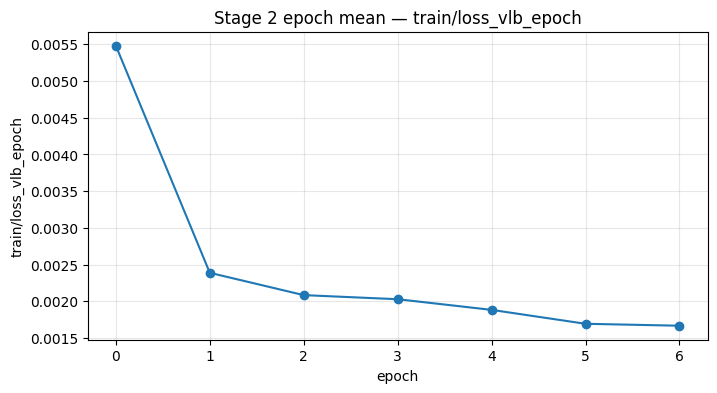

In [22]:
if "epoch" in stage2_df.columns:
    for col in ["train/loss_simple_epoch", "train/loss_epoch", "train/loss_vlb_epoch"]:
        if col in stage2_df.columns:
            tmp = stage2_df[["epoch", col]].dropna().groupby("epoch", as_index=False).mean()
            plt.figure(figsize=(8, 4))
            plt.plot(tmp["epoch"], tmp[col], marker="o")
            plt.xlabel("epoch")
            plt.ylabel(col)
            plt.title(f"Stage 2 epoch mean — {col}")
            plt.grid(True, alpha=0.3)
            plt.show()


## 9. Sampling

Once stage 2 is trained, `mlp_sampling.py` generates new weight vectors.

In our run, sampling produced:

- condition shape: `[10, 10, 5, 512]`
- sampled weight shape: `[10, 2864]`

Each sampled row is one generated network.


### Sampling command

```bash
python mlp_sampling.py --base checkpoints/stage2/config.yaml
```

Typical quick debug prints:

```python
print("cond shape:", xc.shape)
print("sampled shape:", weight.shape)
```


In [25]:
# Load generated samples if they were saved
if SAMPLED_WEIGHTS_FILE.exists():
    sampled = torch.load(SAMPLED_WEIGHTS_FILE, map_location="cpu", weights_only=False)
    print(type(sampled))
    if hasattr(sampled, "shape"):
        print("sampled shape:", sampled.shape)
else:
    print("Sample file not found:", SAMPLED_WEIGHTS_FILE)


<class 'torch.Tensor'>
sampled shape: torch.Size([10, 2864])


## 10. Evaluating sampled networks on MNIST

Sampling alone is not enough. A generated sample is only useful if it can be turned back into a CNN and performs meaningfully on MNIST.

The original flattened model had **2464 real parameters**, so the extra dimensions in the sampled `2864` vector are just padding and should be ignored.


In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.module_list = nn.ModuleList([
            nn.Conv2d(1, 8, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 6, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(6, 4, 2),
            nn.ReLU(),

            nn.Flatten(),
            nn.Linear(36, 20),
            nn.ReLU(),
            nn.Linear(20, 10)
        ])

    def forward(self, x):
        for m in self.module_list:
            x = m(x)
        return x

PARAMS = [
    ("module_list.0.weight", (8,1,5,5)),
    ("module_list.0.bias",   (8,)),
    ("module_list.3.weight", (6,8,5,5)),
    ("module_list.3.bias",   (6,)),
    ("module_list.6.weight", (4,6,2,2)),
    ("module_list.6.bias",   (4,)),
    ("module_list.9.weight", (20,36)),
    ("module_list.9.bias",   (20,)),
    ("module_list.11.weight",(10,20)),
    ("module_list.11.bias",  (10,))
]

def vec_to_state(vec):
    vec = vec.detach().float().cpu().flatten()[:2464]  # remove padding
    state = {}
    i = 0
    for name, shape in PARAMS:
        n = int(torch.tensor(shape).prod().item())
        state[name] = vec[i:i+n].view(shape).clone()
        i += n
    return state

test_loader = DataLoader(
    datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor()),
    batch_size=256,
    shuffle=False
)

@torch.no_grad()
def eval_model(model):
    model.eval()
    total = 0
    correct = 0
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total


sample 0: acc = 0.1009
sample 1: acc = 0.1601
sample 2: acc = 0.1032
sample 3: acc = 0.1032
sample 4: acc = 0.1034
sample 5: acc = 0.1292
sample 6: acc = 0.1062
sample 7: acc = 0.1018
sample 8: acc = 0.1071
sample 9: acc = 0.0958
mean: 0.11109
max: 0.1601


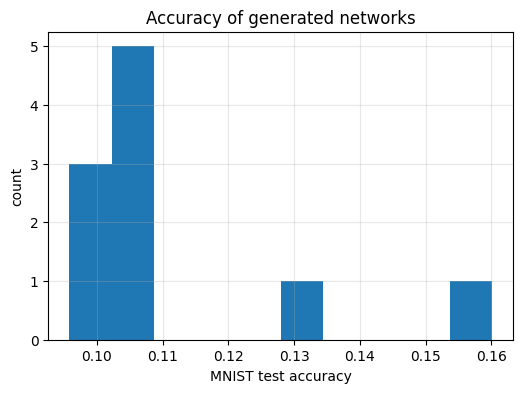

In [27]:
if SAMPLED_WEIGHTS_FILE.exists():
    sampled = torch.load(SAMPLED_WEIGHTS_FILE, map_location="cpu", weights_only=False)
    if sampled.ndim == 1:
        sampled = sampled.unsqueeze(0)

    accs = []
    for i in range(sampled.shape[0]):
        net = Net().to(DEVICE)
        state = vec_to_state(sampled[i])
        net.load_state_dict(state, strict=True)
        acc = eval_model(net)
        accs.append(acc)
        print(f"sample {i}: acc = {acc:.4f}")

    print("mean:", sum(accs) / len(accs))
    print("max:", max(accs))

    plt.figure(figsize=(6, 4))
    plt.hist(accs, bins=min(10, len(accs)))
    plt.xlabel("MNIST test accuracy")
    plt.ylabel("count")
    plt.title("Accuracy of generated networks")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Sample file not found:", SAMPLED_WEIGHTS_FILE)


## 11. How to interpret results

### VAE
- good sign: reconstruction loss decreases and plateaus lower over time
- warning sign: flat reconstruction loss, exploding `logvar`, or NaNs

### Diffusion
- good sign: `train/loss_simple_*` and `val/loss_simple` are finite and slowly decrease
- warning sign: instability, NaNs, or validation much worse than training

### Generated networks
- around **0.10 accuracy** on MNIST: near-random
- noticeably above **0.10**: some structure learned
- strong samples should move substantially higher as training improves


## 12. Next improvements

1. Train the VAE longer  
2. Train diffusion longer  
3. Compare generated-network accuracy against the original zoo  
4. Evaluate VAE reconstructions directly to separate **VAE quality** from **diffusion quality**
